<a href="https://colab.research.google.com/github/maahnumz/low-fp-intrusion-detection/blob/main/intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import libraries

Import the Python libraries needed for this project.  
This includes tools for data handling (pandas, numpy), visualization (matplotlib), and machine learning models and utilities from scikit-learn.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_curve

### Load the KDD Cup 1999 dataset

Load the 10% version of the KDD Cup 1999 intrusion detection dataset using scikit-learn.  
The dataset contains network connection records with extracted features describing each connection.

In [4]:
from sklearn.datasets import fetch_kddcup99

data = fetch_kddcup99(percent10=True)

X = pd.DataFrame(data.data)
y = pd.Series(data.target)

print(X.shape)

(494021, 41)


### Convert labels to binary

The dataset originally contains many different attack types.  
For this project, the labels are simplified to a binary problem:  
0 = normal traffic  
1 = attack traffic.

In [5]:
y = y.apply(lambda x: 0 if x == b'normal.' else 1)

print(y.value_counts())

1    396743
0     97278
Name: count, dtype: int64


### Identify categorical and numeric features

The dataset contains both numeric and categorical features.  
Columns 1, 2, and 3 represent protocol type, service, and connection flag, which are categorical variables.  
The remaining columns are treated as numeric features.

In [6]:
categorical = [1,2,3]
numeric = [i for i in range(41) if i not in categorical]


### Build preprocessing pipeline

Create a preprocessing pipeline that prepares the data before training the models.

Numeric features are standardized using StandardScaler.  
Categorical features are converted into one-hot encoded vectors so they can be used by the models.

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])

### Check class distribution

Look at how many samples belong to each class.  
This helps understand whether the dataset is balanced and how common attack traffic is compared to normal traffic.

In [8]:
print("Class distribution:")
print(y.value_counts(normalize=True))

Class distribution:
1    0.803089
0    0.196911
Name: proportion, dtype: float64


### Train–test split

Split the dataset into training and testing sets.  
The training set is used to fit the models, while the test set is used to evaluate how well the models perform on unseen data.

Stratified sampling is used so the class distribution remains similar in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(395216, 41) (98805, 41)
1    0.80309
0    0.19691
Name: proportion, dtype: float64
1    0.803087
0    0.196913
Name: proportion, dtype: float64


### Train Logistic Regression model

Create a pipeline that first preprocesses the data and then trains a Logistic Regression classifier.

This serves as a baseline model to compare against more complex models later.

In [10]:
lr_pipeline = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  [0, 4, 5, 6, 7, 8, 9, 10, 11,
                                                   12, 13, 14, 15, 16, 17, 18,
                                                   19, 20, 21, 22, 23, 24, 25,
                                                   26, 27, 28, 29, 30, 31, 32, ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [1, 2, 3])])),
                ('model', LogisticRegression(max_iter=1000))])

### Evaluate Logistic Regression performance

Use the test set to evaluate the trained model.  
The confusion matrix and classification report show precision, recall, and F1-score for both normal and attack traffic.

In [11]:
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
[[19394    62]
 [   91 79258]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19456
           1       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



### Train Random Forest model

Train a Random Forest classifier using the same preprocessing pipeline.  
Random Forest is a tree-based ensemble method and often performs well on structured datasets like this one.

In [12]:
rf_pipeline = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(n_estimators=100, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
[[19448     8]
 [   15 79334]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19456
           1       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



### Low false-positive threshold evaluation

In real intrusion detection systems, false alarms must be kept low so that
security analysts are not overwhelmed with alerts.

Instead of using the default classification threshold, the model predictions
are analyzed using an ROC curve. A threshold is selected that keeps the false
positive rate below a target level, and the corresponding detection rate is
measured.

In [13]:
# Get predicted probabilities for the attack class
rf_probs = rf_pipeline.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

# Choose threshold where FPR is closest to 1%
target_fpr = 0.01
idx = np.argmin(np.abs(fpr - target_fpr))

threshold = thresholds[idx]

print("Chosen threshold:", threshold)
print("False Positive Rate:", fpr[idx])
print("True Positive Rate (Attack Recall):", tpr[idx])

Chosen threshold: 0.03
False Positive Rate: 0.011153371710526315
True Positive Rate (Attack Recall): 1.0


In [14]:
# Apply the low-FPR threshold
y_pred_low_fp = (rf_probs >= threshold).astype(int)

print("Confusion Matrix (Low-FPR Threshold)")
print(confusion_matrix(y_test, y_pred_low_fp))

print("\nClassification Report")
print(classification_report(y_test, y_pred_low_fp))

Confusion Matrix (Low-FPR Threshold)
[[19239   217]
 [    0 79349]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19456
           1       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      0.99      1.00     98805
weighted avg       1.00      1.00      1.00     98805



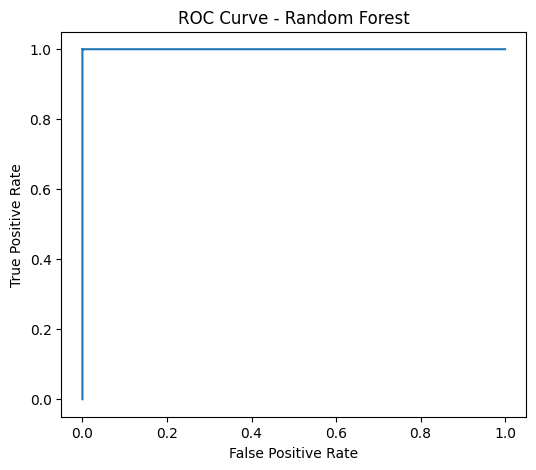

In [15]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

### Remove duplicate records

The KDD Cup 1999 dataset contains many duplicate network connection records.  
These duplicates can artificially inflate model performance because very similar
samples may appear in both the training and test sets.

To reduce this issue, duplicate records are removed before training the models.

In [16]:
# Combine features and labels
df_full = X.copy()
df_full['label'] = y

print("Original dataset size:", df_full.shape)

# Remove duplicates
df_dedup = df_full.drop_duplicates()

print("After removing duplicates:", df_dedup.shape)

# Split back into X and y
X_dedup = df_dedup.drop('label', axis=1)
y_dedup = df_dedup['label']

Original dataset size: (494021, 42)
After removing duplicates: (145585, 42)


In [18]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dedup, y_dedup, test_size=0.2, random_state=42, stratify=y_dedup
)

In [19]:
rf_pipeline.fit(X_train_d, y_train_d)

y_pred_rf_d = rf_pipeline.predict(X_test_d)

print("Random Forest Results (Deduplicated Data)")
print(confusion_matrix(y_test_d, y_pred_rf_d))
print(classification_report(y_test_d, y_pred_rf_d))

Random Forest Results (Deduplicated Data)
[[17561     5]
 [   16 11535]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17566
           1       1.00      1.00      1.00     11551

    accuracy                           1.00     29117
   macro avg       1.00      1.00      1.00     29117
weighted avg       1.00      1.00      1.00     29117



### Address dataset redundancy

The KDD Cup 1999 dataset contains a large number of duplicate records.  
If duplicates appear in both the training and testing sets, models may appear to perform better than they would in a real deployment.

To reduce this issue, duplicate records are removed and the models are trained again on the cleaned dataset.

### Observations

After removing duplicates, the dataset size decreases significantly, indicating that many network connections in KDD99 are repeated.

Even with the reduced dataset, the Random Forest model still achieves very high detection performance, suggesting that the features in the dataset strongly separate normal and attack traffic.